In [1]:

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


In [2]:
DATA_PATH=Path("data/yahoo_stock_for_preprocessing.csv")
df=pd.read_csv(DATA_PATH,index_col='Date', parse_dates=True)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1825 entries, 2015-11-23 to 2020-11-20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   High        1825 non-null   float64
 1   Low         1825 non-null   float64
 2   Open        1825 non-null   float64
 3   Close       1825 non-null   float64
 4   Volume      1825 non-null   float64
 5   Adj Close   1825 non-null   float64
 6   return      1824 non-null   float64
 7   log_return  1824 non-null   float64
dtypes: float64(8)
memory usage: 128.3 KB


In [3]:
df.index.dtype

dtype('<M8[us]')

In [4]:
assert df.index.is_monotonic_increasing

In [5]:
print(f'{len(df)}')

1825


In [6]:
df=df.drop(['return','log_return'],axis=1)

### Quick sanity check

In [7]:
df.index.is_monotonic_increasing

True

In [8]:
df.isna().sum()

High         0
Low          0
Open         0
Close        0
Volume       0
Adj Close    0
dtype: int64

In [9]:
df.shape

(1825, 6)

### train/val/test split (70/15/15)

In [10]:
train_end=int(len(df)*0.70)
val_end = int(len(df) * 0.85)
print(train_end,val_end)

1277 1551


In [11]:
train=df.iloc[:train_end]
val=df.iloc[train_end:val_end]
test=df.iloc[val_end:]

### check the len

In [12]:
print(f'Train: {len(train)} | Validation: {len(val)} | Test: {len(test)}')

Train: 1277 | Validation: 274 | Test: 274


### ckeck date range

In [13]:
print(f'Train: {train.index.min()}  {train.index.max()} | Validation: {val.index.min()} {val.index.max()} | Test: {test.index.min()} {test.index.max()}')

Train: 2015-11-23 00:00:00  2019-05-22 00:00:00 | Validation: 2019-05-23 00:00:00 2020-02-20 00:00:00 | Test: 2020-02-21 00:00:00 2020-11-20 00:00:00


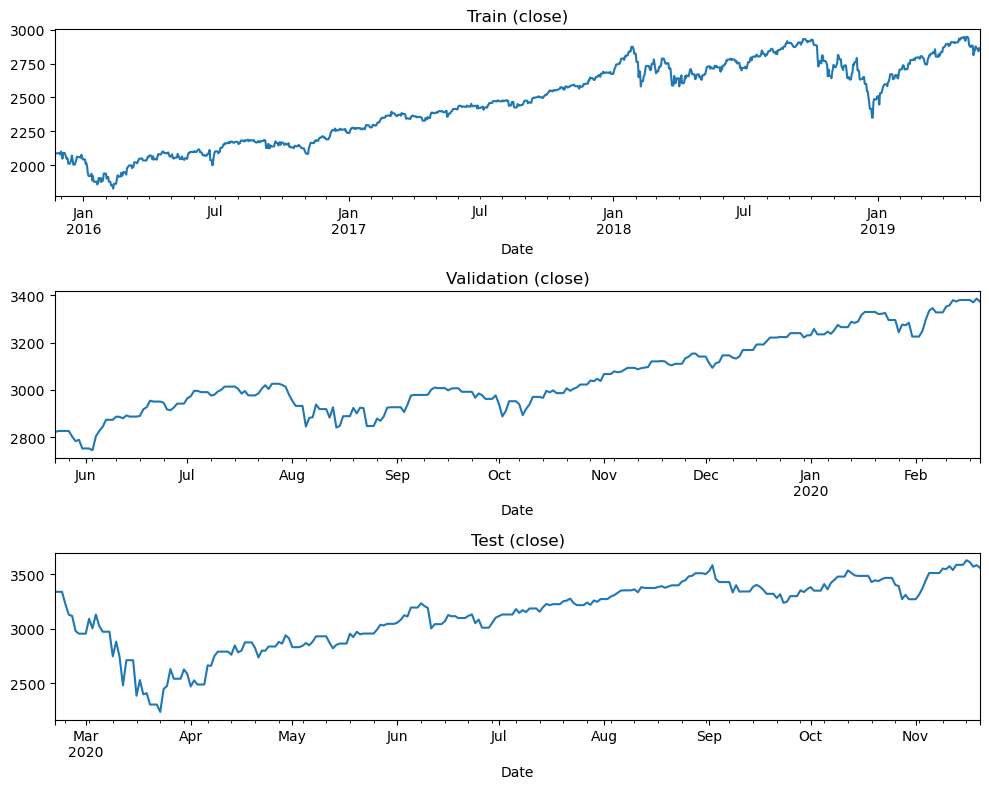

In [14]:
fig,axes = plt.subplots(3, 1, figsize=(10, 8))
train['Close'].plot(ax=axes[0],title='Train (close)')
val['Close'].plot(ax=axes[1],title='Validation (close)')
test['Close'].plot(ax=axes[2],title='Test (close)')
plt.tight_layout()
plt.show()

In [15]:
train.to_csv('data/train.csv')
val.to_csv('data/val.csv')
test.to_csv('data/test.csv')